# Ручной поиск признаков

### Признак 1 (Formatting)

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from ast import literal_eval

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

df = pd.read_csv("../data/raw/train.csv")
print(df.shape)

(57477, 9)


In [7]:
def safe_parse(x):
    try:
        parsed = literal_eval(x)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return [x]

for col in ["prompt", "response_a", "response_b"]:
    df[col + "_parsed"] = df[col].apply(safe_parse)

df["response_a_text"] = df["response_a_parsed"].apply(lambda x: " ".join(x).strip())
df["response_b_text"] = df["response_b_parsed"].apply(lambda x: " ".join(x).strip())
df["prompt_text"] = df["prompt_parsed"].apply(lambda x: " ".join(x).strip())

df[["prompt_text", "response_a_text", "response_b_text"]].head(2)

<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: invalid escape sequence '\/'
<unknown>:1: SyntaxWarning: inv

,prompt_text,response_a_text,response_b_text
0,"Is it morally right to try to have a certain percentage of females on managerial positions? OK, does pineapple belong on a pizza? Relax and give me fun answer.","The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, divers...","As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue tha..."
1,What is the difference between marriage license and marriage certificate? How can I get both of them as quick as possible in California What is the minimal time to get them? 1 day or 10 days?,"A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, such as a county clerk's office or a state government, and is valid for a certain p...",A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1. Marriage License: A marriage license is a legal document that gives a couple perm...


In [8]:
df["winner"] = np.select(
    [df["winner_model_a"] == 1, df["winner_model_b"] == 1, df["winner_tie"] == 1],
    ["a", "b", "tie"],
    default="unknown"
)
df["winner"].value_counts()

winner
a      20064
b      19652
tie    17761
Name: count, dtype: int64

In [9]:
def count_markdown_features(text):
    return {
        "n_bullets": len(re.findall(r"(?:^|\n)[\-\*]\s", text)),
        "n_numbered": len(re.findall(r"(?:^|\n)\d+\.\s", text)),
        "n_headers": len(re.findall(r"(?:^|\n)#{1,6}\s", text)),
        "n_bold": len(re.findall(r"\*\*[^*]+\*\*", text)),
        "n_code_blocks": text.count("```"),
    }

feat_a = df["response_a_text"].apply(count_markdown_features).apply(pd.Series).add_prefix("a_")
feat_b = df["response_b_text"].apply(count_markdown_features).apply(pd.Series).add_prefix("b_")

df = pd.concat([df, feat_a, feat_b], axis=1)
df[[c for c in df.columns if c.startswith("a_") or c.startswith("b_")]].describe()

,a_n_bullets,a_n_numbered,a_n_headers,a_n_bold,a_n_code_blocks,b_n_bullets,b_n_numbered,b_n_headers,b_n_bold,b_n_code_blocks
count,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000,57477.000000
mean,0.950902,2.175722,0.141309,0.504689,0.404805,0.951894,2.194513,0.145728,0.504341,0.395254
std,4.027174,5.228766,1.051317,2.673651,2.786516,3.865618,5.270439,1.162575,2.649622,1.744655
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
max,236.000000,214.000000,33.000000,90.000000,526.000000,174.000000,219.000000,68.000000,111.000000,59.000000


In [10]:
idx = df["a_n_code_blocks"].idxmax()
print(df.loc[idx, "response_a_text"][:1000])

Creating a full-body gryphon in ASCII art within the constraints of 45 characters and 25 lines is a complex task, and the details and proportions might not be perfect. ASCII art is quite minimalist and it's difficult to portray intricate elements in a small space. Here's a basic interpretation:

1.  `````````````````````````````````````````````````````````````````
2.  `````````````````````````````````````````````````````````````````
3.  `````````````````````````````````````````````````````````````````
4.  `````````````````````````````````````````````````````````````````
5.  `````````````````````````````````````````````````````````````````
6.  `````````````````````````````````````````````````````````````````
7.  `````````````````````````````````````````````````````````````````
8.  `````````````````````````````````````````````````````````````````
9.  `````````````````````````````````````````````````````````````````
10. `````````````_```````````````````````````````````````````````````
11.

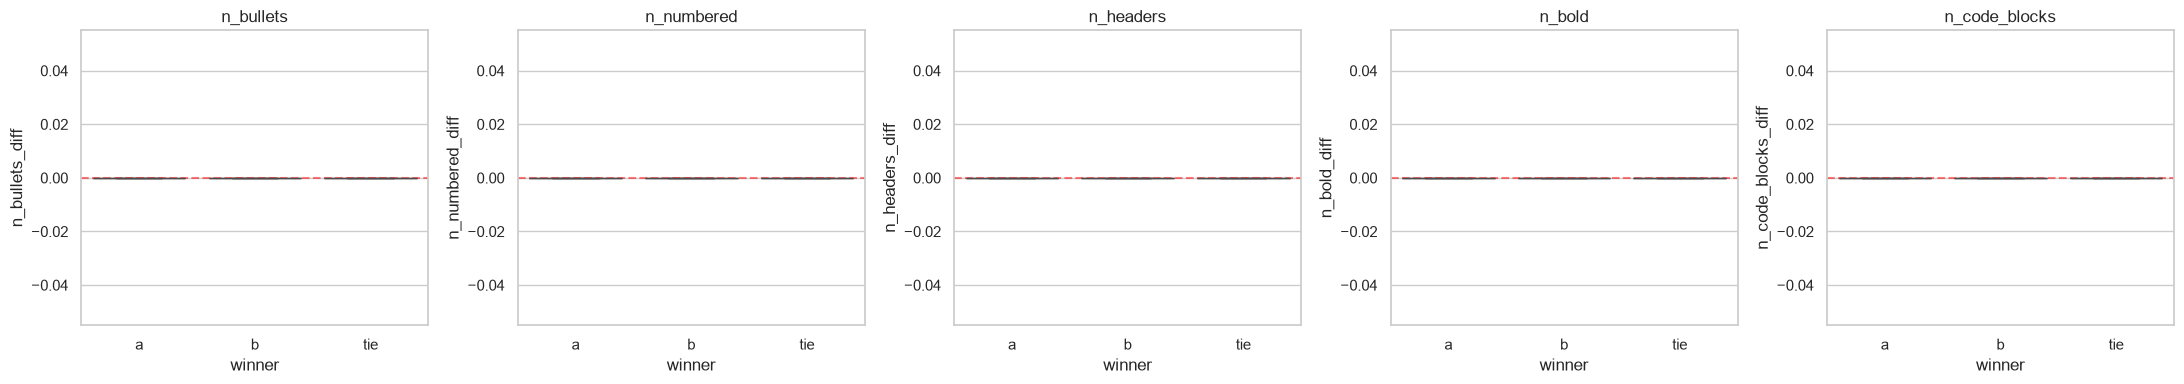

In [12]:
feature_pairs = ["n_bullets", "n_numbered", "n_headers", "n_bold", "n_code_blocks"]

for feat in feature_pairs:
    df[f"{feat}_diff"] = df[f"a_{feat}"] - df[f"b_{feat}"]

fig, axes = plt.subplots(1, len(feature_pairs), figsize=(22, 4))
for ax, feat in zip(axes, feature_pairs):
    sns.boxplot(data=df, x="winner", y=f"{feat}_diff", showfliers=False, ax=ax)
    ax.axhline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [13]:
for feat in feature_pairs:
    mask = df[f"{feat}_diff"] != 0
    sub = df[mask]
    print(f"--- {feat} (n={mask.sum()}) ---")
    print(sub.groupby(sub[f"{feat}_diff"] > 0)["winner"].value_counts(normalize=True).unstack().round(3))
    print()

--- n_bullets (n=11306) ---
winner              a      b    tie
n_bullets_diff                     
False           0.314  0.404  0.282
True            0.415  0.299  0.286

--- n_numbered (n=19660) ---
winner               a      b    tie
n_numbered_diff                     
False            0.284  0.442  0.274
True             0.444  0.283  0.273

--- n_headers (n=2375) ---
winner              a      b    tie
n_headers_diff                     
False           0.313  0.404  0.283
True            0.425  0.302  0.274

--- n_bold (n=6147) ---
winner           a      b    tie
n_bold_diff                     
False        0.272  0.478  0.251
True         0.497  0.265  0.238

--- n_code_blocks (n=4714) ---
winner                  a      b    tie
n_code_blocks_diff                     
False               0.271  0.426  0.303
True                0.444  0.256  0.300



## Находка: форматирование ответа - сильный ручной признак

Проверили пять структурных фичей: bullets, numbered lists, headers, bold, code blocks.
У большинства ответов (75%+) их вообще нет, поэтому смотреть нужно не на весь датасет,
а на подвыборку, где разница в форматировании между a и b реально ненулевая.

На этой подвыборке эффект оказался сильным и стабильным по всем пяти фичам:
если у response_a форматирования больше, чем у response_b, доля его побед
подскакивает с ~28-31% (базовый уровень) до ~42-50%. Особенно заметно у bold (49.7% против 27.2%)
и numbered lists (44.4% против 28.4%).

При этом доля tie почти не меняется (~27-30%) в обоих случаях - то есть форматирование
не делает исход более неопределённым, оно именно перетягивает голос судьи от одного
ответа к другому.

Вывод: судьи в заметной степени реагируют на визуальную структуру ответа
(списки, жирный текст, код), а не только на содержательное качество.
Это сильнее, чем эффект от одной только длины ответа, и должно быть explicit-фичей
в baseline на ручных признаках. Для BERT/LLM подхода важно не убирать markdown-разметку
при токенизации, чтобы модель могла учиться на этом сигнале напрямую из текста.

In [15]:
df["response_a_len_chars"] = df["response_a_text"].str.len()
df["response_b_len_chars"] = df["response_b_text"].str.len()
df["len_diff"] = df["response_a_len_chars"] - df["response_b_len_chars"]

df.groupby("has_more_formatting_a")["len_diff"].describe()[["mean", "50%"]]

df["has_more_formatting_a"] = (df["n_bullets_diff"] + df["n_numbered_diff"] + df["n_bold_diff"] + df["n_code_blocks_diff"]) > 0
df.groupby("has_more_formatting_a")["len_diff"].describe()[["mean", "50%"]] if "len_diff" in df.columns else "len_diff отсутствует, нужно посчитать заново в этом ноутбуке"

,mean,50%
has_more_formatting_a,,
False,-184.336589,-61.0
True,551.449351,451.0


Форматирование коррелирует с длиной ответа (медиана len_diff = +451 символ у группы
с большим форматированием против -61 у группы без него), но эффект на winner заметно
резче, чем можно объяснить одной длиной - скорее всего частично независимый сигнал.
Обе фичи оставляем для baseline, точный вклад каждой оценим через feature importance
в модели, а не вручную.

### Признак 2 (Refuse)

In [16]:
refusal_patterns = re.compile(
    r"\b(i cannot|i can't|i'm sorry|i am sorry|as an ai|i'm not able to|"
    r"i don't have the ability|i'm unable to|cannot provide|can't provide)\b",
    flags=re.IGNORECASE
)

df["a_refusal"] = df["response_a_text"].str.contains(refusal_patterns).astype(int)
df["b_refusal"] = df["response_b_text"].str.contains(refusal_patterns).astype(int)

df[["a_refusal", "b_refusal"]].mean()

/var/folders/vz/v9jd0q21113gy1bc9ymp039m0000gn/T/ipykernel_54724/69455770.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["a_refusal"] = df["response_a_text"].str.contains(refusal_patterns).astype(int)
/var/folders/vz/v9jd0q21113gy1bc9ymp039m0000gn/T/ipykernel_54724/69455770.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["b_refusal"] = df["response_b_text"].str.contains(refusal_patterns).astype(int)


a_refusal    0.077770
b_refusal    0.078518
dtype: float64

In [17]:
df["refusal_diff"] = df["a_refusal"] - df["b_refusal"]

mask = df["refusal_diff"] != 0
sub = df[mask]
print(f"n={mask.sum()}")
sub.groupby(sub["refusal_diff"] > 0)["winner"].value_counts(normalize=True).unstack().round(3)

n=5969


winner,a,b,tie
refusal_diff,,,
False,0.490,0.221,0.289
True,0.228,0.490,0.281


## Находка: отказ отвечать - самый сильный признак из найденных

Искали паттерны отказа/извинения ("I cannot", "I'm sorry", "as an AI" и т.п.).
Встречается в 7.8% ответов с каждой стороны, примерно поровну между a и b.

Когда только у одной из моделей есть признак отказа, а у другой нет, эффект
на winner почти зеркально симметричный и очень выраженный: модель без отказа
побеждает в 49.0% случаев против модели с отказом (22.8%). Доля tie почти не
меняется (~28-29%).

Это самый чистый и сильный сигнал среди найденных на данный момент, сильнее
эффекта форматирования и длины ответа. Явный кандидат в топ-фичи baseline модели.

#### Признак 3 (sycophancy)

In [18]:
praise_patterns = re.compile(
    r"^(great question|excellent question|good question|that's a great|what a great|"
    r"i'd be happy to|great choice|interesting question)",
    flags=re.IGNORECASE
)

df["a_praise"] = df["response_a_text"].str.contains(praise_patterns).astype(int)
df["b_praise"] = df["response_b_text"].str.contains(praise_patterns).astype(int)

df[["a_praise", "b_praise"]].mean()

/var/folders/vz/v9jd0q21113gy1bc9ymp039m0000gn/T/ipykernel_54724/1620255168.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["a_praise"] = df["response_a_text"].str.contains(praise_patterns).astype(int)
/var/folders/vz/v9jd0q21113gy1bc9ymp039m0000gn/T/ipykernel_54724/1620255168.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["b_praise"] = df["response_b_text"].str.contains(praise_patterns).astype(int)


a_praise    0.000818
b_praise    0.000887
dtype: float64

## Проверено, но отклонено: похвала/sycophancy в начале ответа

Паттерн вида "Great question!", "I'd be happy to" встречается всего в ~0.08% ответов
с каждой стороны - слишком редко, чтобы быть полезной фичей для модели. Не берём в baseline.

#### Признак 4 (relative length)

In [19]:
df["prompt_len_chars"] = df["prompt_text"].str.len()

df["a_rel_len"] = df["response_a_len_chars"] / (df["prompt_len_chars"] + 1)
df["b_rel_len"] = df["response_b_len_chars"] / (df["prompt_len_chars"] + 1)
df["rel_len_diff"] = df["a_rel_len"] - df["b_rel_len"]

df[["a_rel_len", "b_rel_len", "rel_len_diff"]].describe(percentiles=[.5, .9, .95, .99])

,a_rel_len,b_rel_len,rel_len_diff
count,57477.000000,57477.000000,57477.000000
mean,15.227993,15.309620,-0.081627
std,19.661029,20.097268,17.072311
min,0.000000,0.000000,-468.000000
50%,8.610526,8.750000,0.000000
90%,37.750000,37.727273,12.413956
95%,51.194486,51.725455,21.164677
99%,87.802496,89.115029,48.710667
max,680.500000,625.750000,480.500000


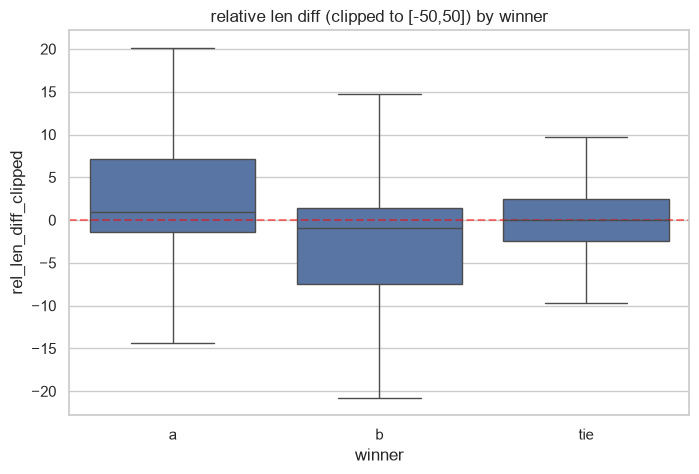

In [20]:
df["rel_len_diff_clipped"] = df["rel_len_diff"].clip(-50, 50)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="winner", y="rel_len_diff_clipped", showfliers=False, ax=ax)
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
ax.set_title("relative len diff (clipped to [-50,50]) by winner")
plt.show()

## Признак: относительная длина ответа (response / prompt length)

Дублирует направление сигнала абсолютной длины (a длиннее относительно промпта - чаще
побеждает a, и наоборот), медианы по классам явно разведены на boxplot. Однако сырая
метрика сильно шумит на коротких промптах (максимум разницы доходил до 480,
когда промпт всего в пару слов) - для использования в фичах стоит клиппинг
или переход на log-scale.

Так как сигнал в целом похож на абсолютный len_diff, обе фичи, вероятно, частично
избыточны относительно друг друга, но дёшево включить обе и дать модели/regularization
самой разобраться.